In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/lab05/q01.csv')

df.drop_duplicates()

X = df[['restecg', 'oldpeak']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

results = {}
for scheme in ['hard', 'soft']:
  models = {
    'rf': RandomForestClassifier(random_state=0),
    'xg': XGBClassifier(random_state=0),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'dt': DecisionTreeClassifier(random_state=0)
  }

  vc = VotingClassifier(estimators=list(models.items()), voting=scheme)

  vc.fit(X_train, y_train)
  results[scheme] = {
    'accuracy': vc.score(X_test, y_test),
    'vc': vc
  }

best_models = results[max(results, key=lambda k: results[k]['accuracy'])]

for name, model in best_models['vc'].named_estimators_.items():
  print(name)
  try:
    print(model.feature_importances_)
  except:
    print('No Feature Importances')

rf
[0.10032458 0.89967542]
xg
[0.30532113 0.6946789 ]
knn
No Feature Importances
dt
[0.11917688 0.88082312]


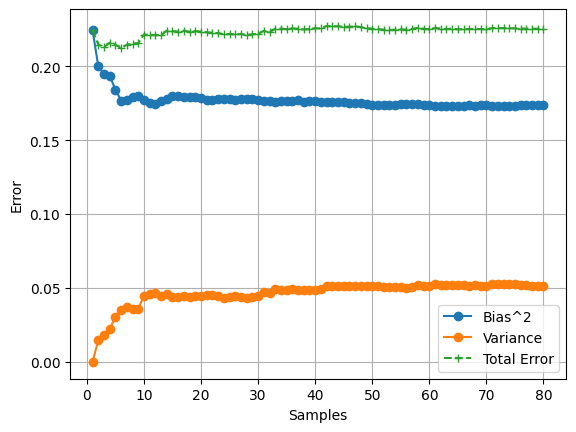

In [3]:
from sklearn.utils import resample

N = 80

preds = []
for i in range(N):
  X_s, y_s = resample(X_train, y_train, random_state=i)
  vc.fit(X_s, y_s)
  pred = vc.predict(X_test)
  preds.append(pred)

biases, variances = [], []
for k in range(1, N+1):
  prefix_preds = preds[:k]
  mean_preds = np.mean(prefix_preds, axis=0)
  bias2 = np.mean((mean_preds - y_test)**2)
  var = np.mean(np.var(prefix_preds, axis=0))
  biases.append(bias2)
  variances.append(var)

total = np.array(biases) + np.array(variances)
plt.plot(range(1, N+1), biases, label="Bias^2", marker='o')
plt.plot(range(1, N+1), variances, label="Variance", marker='o')
plt.plot(range(1, N+1), total, label="Total Error", marker='+', linestyle='--')
plt.xlabel('Samples')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()
